# Team505 — Exploratory Data Analysis (EDA)

**DSAI 305 — Phase 2**  
**Dataset:** NIH ChestX-ray14  
**Task:** Binary Pneumonia Classification  

This notebook provides a comprehensive exploratory analysis of the preprocessed dataset.  
All split CSVs were generated by `Team505_Preprocessing.ipynb` and are loaded from `data/splits/`.

---

**Sections:**
1. Dataset Overview
2. Split Overview
3. Class Imbalance Analysis
4. Patient-Level Analysis
5. Demographic Analysis
6. View Position Analysis
7. Sample Image Visualization
8. Image Property Checks
9. Key EDA Findings
10. Figure Export Summary

## 0 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# ---- Style ----
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
})

# ---- Paths ----
PROJECT_ROOT = Path('..').resolve()
DATA_SPLITS  = PROJECT_ROOT / 'data' / 'splits'
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw' / 'nih_chest_xray14'
EDA_OUTPUT   = PROJECT_ROOT / 'outputs' / 'eda'
EDA_OUTPUT.mkdir(parents=True, exist_ok=True)

# ---- Color palette ----
COLORS = {
    'pos': '#e74c3c',      # red for pneumonia
    'neg': '#2ecc71',      # green for non-pneumonia
    'train': '#3498db',    # blue
    'val': '#f39c12',      # orange
    'test': '#9b59b6',     # purple
    'train_dev': '#1abc9c' # teal
}

print(f'Project root : {PROJECT_ROOT}')
print(f'Split CSVs   : {DATA_SPLITS}')
print(f'EDA output   : {EDA_OUTPUT}')

Project root : C:\Users\s-amm\Downloads\ChestX-ray14\Team505_phase2
Split CSVs   : C:\Users\s-amm\Downloads\ChestX-ray14\Team505_phase2\data\splits
EDA output   : C:\Users\s-amm\Downloads\ChestX-ray14\Team505_phase2\outputs\eda


## 0.1 — Load Split CSVs

In [2]:
# Load all splits
df_train     = pd.read_csv(DATA_SPLITS / 'train.csv')
df_val       = pd.read_csv(DATA_SPLITS / 'val.csv')
df_test      = pd.read_csv(DATA_SPLITS / 'test.csv')
df_train_dev = pd.read_csv(DATA_SPLITS / 'train_dev.csv')

# Combined full dataset (train + val + test)
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Also load original metadata for follow-up counts
meta_path = DATA_RAW / 'Data_Entry_2017.csv'
df_meta = pd.read_csv(meta_path)

print('Split CSVs loaded successfully.')
print(f'  train.csv     : {len(df_train):>8,} rows')
print(f'  val.csv       : {len(df_val):>8,} rows')
print(f'  test.csv      : {len(df_test):>8,} rows')
print(f'  train_dev.csv : {len(df_train_dev):>8,} rows')
print(f'  TOTAL (excl. dev): {len(df_all):>8,} rows')

Split CSVs loaded successfully.
  train.csv     :   73,916 rows
  val.csv       :   12,608 rows
  test.csv      :   25,596 rows
  train_dev.csv :    8,085 rows
  TOTAL (excl. dev):  112,120 rows


---
## 1 — Dataset Overview

High-level statistics for the entire NIH ChestX-ray14 dataset, after preprocessing.

In [3]:
total_images   = len(df_all)
total_patients = df_all['patient_id'].nunique()
total_pos      = df_all['target_pneumonia'].sum()
total_neg      = total_images - total_pos
pos_rate       = total_pos / total_images

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total images         : {total_images:>10,}')
print(f'Total patients       : {total_patients:>10,}')
print(f'Pneumonia positives  : {total_pos:>10,}')
print(f'Pneumonia negatives  : {total_neg:>10,}')
print(f'Positive rate        : {pos_rate:>10.4f}  ({pos_rate*100:.2f}%)')
print(f'Images per patient   : {total_images/total_patients:>10.1f}  (mean)')
print('=' * 60)

DATASET OVERVIEW
Total images         :    112,120
Total patients       :     30,805
Pneumonia positives  :      1,431
Pneumonia negatives  :    110,689
Positive rate        :     0.0128  (1.28%)
Images per patient   :        3.6  (mean)


**Observation:** The NIH ChestX-ray14 dataset contains 112,120 chest X-ray images from 30,805 unique patients.  
Only **1.28%** of images are labeled with pneumonia, indicating a severe class imbalance that will require careful handling during model training.

> **Note on label quality:** The NIH ChestX-ray14 labels were **NLP-mined** from radiology reports, not manually annotated by radiologists on a per-image basis. 
Wang et al. (2017) report labeling accuracy above 90%, but some degree of label noise is inherent. 
This means the ground truth is **imperfect**: some pneumonia cases may be missed (false negatives) and some non-pneumonia images may be mislabeled (false positives). 
Model performance should be interpreted with this caveat in mind.

---
## 2 — Split Overview

Detailed breakdown of the train / validation / test splits and the development subset.

In [4]:
# Build summary table
split_summary = []
for name, sdf in [('Train', df_train), ('Validation', df_val), ('Test', df_test), ('Train_dev', df_train_dev)]:
    n = len(sdf)
    p = sdf['patient_id'].nunique()
    pos = sdf['target_pneumonia'].sum()
    neg = n - pos
    pct = pos / n * 100 if n > 0 else 0
    split_summary.append({
        'Split': name,
        'Images': f'{n:,}',
        'Patients': f'{p:,}',
        'Pneumonia+': f'{pos:,}',
        'Pneumonia-': f'{neg:,}',
        'Pos Rate': f'{pct:.2f}%'
    })

df_summary = pd.DataFrame(split_summary)
print(df_summary.to_string(index=False))

# Patient overlap verification
train_pids = set(df_train['patient_id'].unique())
val_pids   = set(df_val['patient_id'].unique())
test_pids  = set(df_test['patient_id'].unique())

print(f'\nPatient overlap checks:')
print(f'  Train / Val  overlap: {len(train_pids & val_pids)}')
print(f'  Train / Test overlap: {len(train_pids & test_pids)}')
print(f'  Val   / Test overlap: {len(val_pids & test_pids)}')
print(f'  [OK] All splits are patient-disjoint.')

     Split Images Patients Pneumonia+ Pneumonia- Pos Rate
     Train 73,916   23,806        742     73,174    1.00%
Validation 12,608    4,202        134     12,474    1.06%
      Test 25,596    2,797        555     25,041    2.17%
 Train_dev  8,085      587        742      7,343    9.18%

Patient overlap checks:
  Train / Val  overlap: 0
  Train / Test overlap: 0
  Val   / Test overlap: 0
  [OK] All splits are patient-disjoint.


**Observation:** The official NIH test split contains 25,596 images from 2,797 patients.  
The train/validation split was created using patient-level grouping (85/15 ratio) to prevent data leakage.  
The `train_dev` subset contains 8,085 images from ALL pneumonia-positive training patients, providing a small but representative development set for rapid iteration.

> **Note on `train_dev`:** The `train_dev.csv` subset is an **enriched debugging subset** created by selecting all pneumonia-positive patients from train. 
Its positive rate (~9.2%) is intentionally much higher than the natural distribution (~1.0%). 
This subset is designed for **rapid prototyping and debugging only**. 
All final model comparisons and reported metrics **must** use the full `train.csv` for training and `val.csv` for validation to ensure a fair and representative evaluation.

---
## 3 — Class Imbalance Analysis

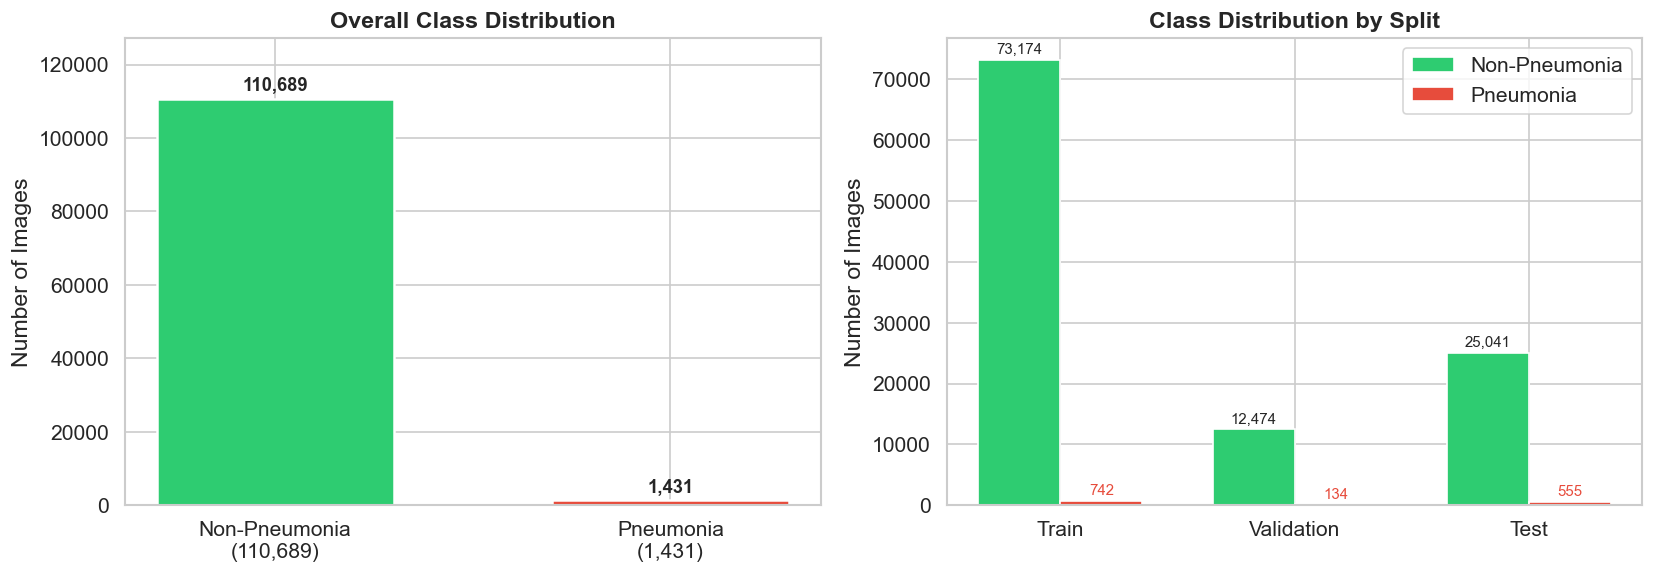

[SAVED] outputs/eda/class_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----- 3a: Overall class distribution -----
ax = axes[0]
counts = [total_neg, total_pos]
labels = [f'Non-Pneumonia\n({total_neg:,})', f'Pneumonia\n({total_pos:,})']
colors = [COLORS['neg'], COLORS['pos']]
bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.6)
ax.set_title('Overall Class Distribution', fontsize=14)
ax.set_ylabel('Number of Images')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)

# ----- 3b: Split-wise comparison -----
ax = axes[1]
split_names = ['Train', 'Validation', 'Test']
split_dfs   = [df_train, df_val, df_test]
x = np.arange(len(split_names))
width = 0.35

neg_counts = [len(s) - s['target_pneumonia'].sum() for s in split_dfs]
pos_counts = [s['target_pneumonia'].sum() for s in split_dfs]

bars1 = ax.bar(x - width/2, neg_counts, width, label='Non-Pneumonia',
               color=COLORS['neg'], edgecolor='white')
bars2 = ax.bar(x + width/2, pos_counts, width, label='Pneumonia',
               color=COLORS['pos'], edgecolor='white')

ax.set_title('Class Distribution by Split', fontsize=14)
ax.set_ylabel('Number of Images')
ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.legend(loc='upper right')

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9,
            color=COLORS['pos'])

plt.tight_layout()
fig.savefig(EDA_OUTPUT / 'class_distribution.png')
plt.show()
print('[SAVED] outputs/eda/class_distribution.png')

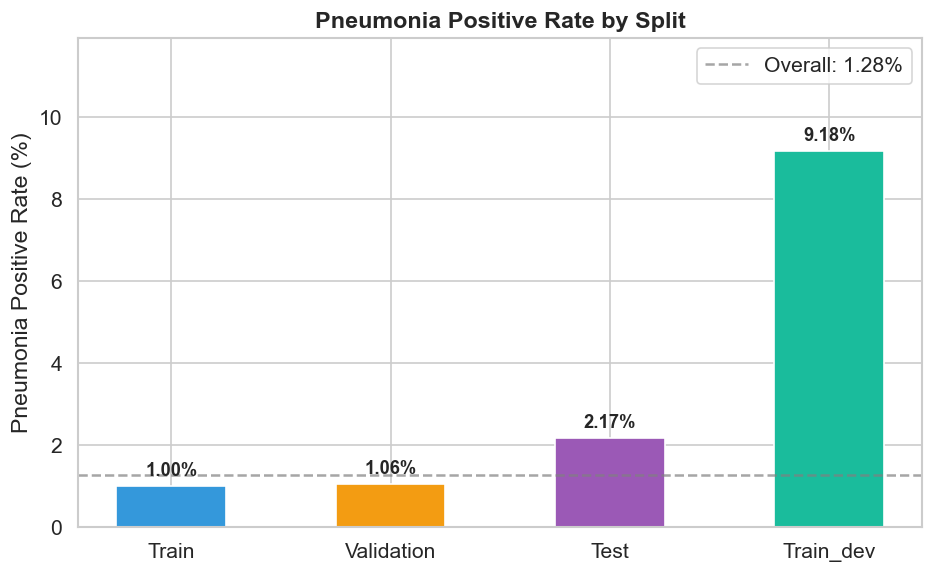

[SAVED] outputs/eda/pos_rate_by_split.png


In [6]:
# Pneumonia positive rate per split — bar chart
fig, ax = plt.subplots(figsize=(8, 5))

split_labels = ['Train', 'Validation', 'Test', 'Train_dev']
pos_rates = [
    df_train['target_pneumonia'].mean() * 100,
    df_val['target_pneumonia'].mean() * 100,
    df_test['target_pneumonia'].mean() * 100,
    df_train_dev['target_pneumonia'].mean() * 100
]
bar_colors = [COLORS['train'], COLORS['val'], COLORS['test'], COLORS['train_dev']]

bars = ax.bar(split_labels, pos_rates, color=bar_colors, edgecolor='white', width=0.5)
ax.set_ylabel('Pneumonia Positive Rate (%)')
ax.set_title('Pneumonia Positive Rate by Split', fontsize=14)

for bar, rate in zip(bars, pos_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, max(pos_rates) * 1.3)
ax.axhline(y=df_all['target_pneumonia'].mean()*100, color='grey',
           linestyle='--', alpha=0.7, label=f'Overall: {df_all["target_pneumonia"].mean()*100:.2f}%')
ax.legend()

plt.tight_layout()
fig.savefig(EDA_OUTPUT / 'pos_rate_by_split.png')
plt.show()
print('[SAVED] outputs/eda/pos_rate_by_split.png')

**Observation:** Severe class imbalance is present across all splits. The pneumonia positive rate is ~1.0% in train/val and ~2.2% in the official NIH test split. The `train_dev` subset was intentionally enriched to ~9.2% by selecting ALL pneumonia-positive patients from train, enabling faster experimentation.  
**Implication:** Weighted loss functions, oversampling, or focal loss should be considered during training.

---
## 4 — Patient-Level Analysis

In [7]:
# Number of images per patient
images_per_patient = df_all.groupby('patient_id').size()

print('Images per patient — Summary Statistics:')
print(images_per_patient.describe().to_string())
print(f'\nPatients with 1 image  : {(images_per_patient == 1).sum():,}')
print(f'Patients with 2+ images: {(images_per_patient >= 2).sum():,}')
print(f'Patients with 5+ images: {(images_per_patient >= 5).sum():,}')
print(f'Patients with 10+ images: {(images_per_patient >= 10).sum():,}')
print(f'Max images per patient : {images_per_patient.max()}')

Images per patient — Summary Statistics:
count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000

Patients with 1 image  : 17,503
Patients with 2+ images: 13,302
Patients with 5+ images: 5,759
Patients with 10+ images: 2,545
Max images per patient : 184


Follow-up # summary:
count    112120.000000
mean          8.573751
std          15.406320
min           0.000000
25%           0.000000
50%           3.000000
75%          10.000000
max         183.000000


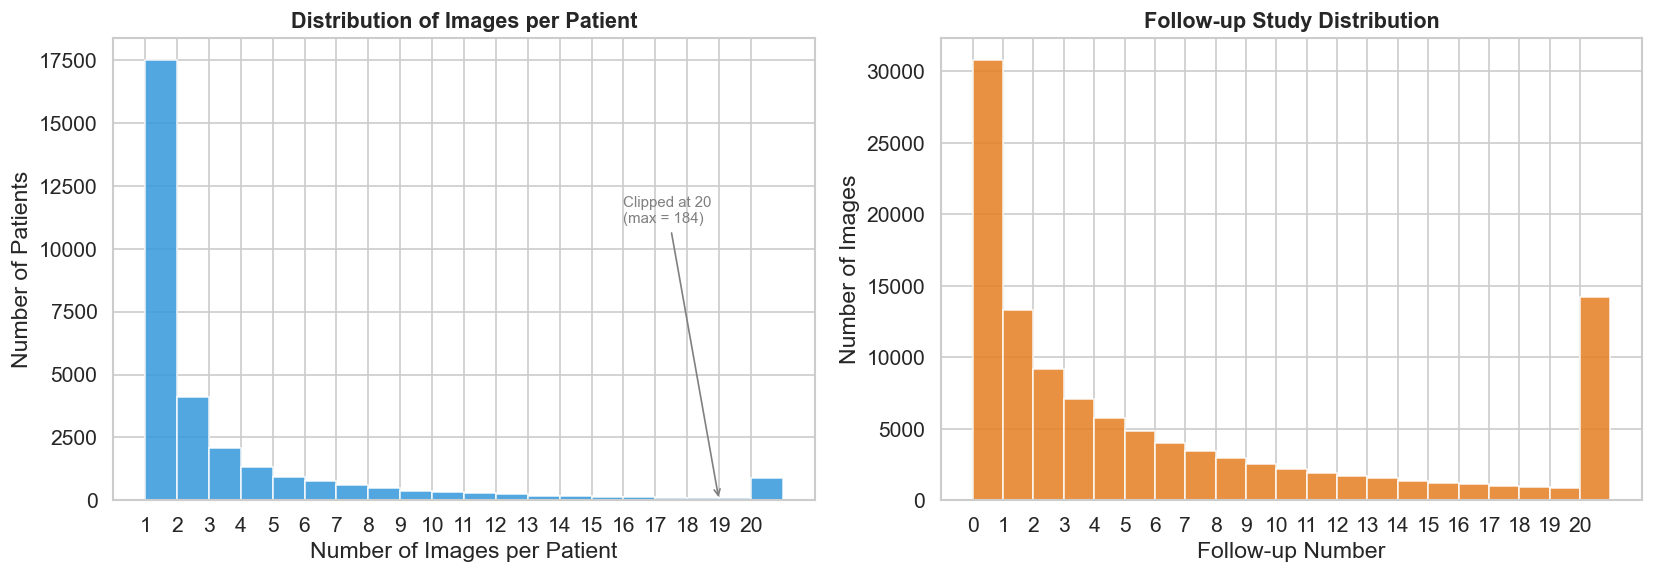

[SAVED] outputs/eda/patient_analysis.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4a: Distribution of images per patient
ax = axes[0]
clipped = images_per_patient.clip(upper=20)  # clip for readability
ax.hist(clipped, bins=range(1, 22), color='#3498db', edgecolor='white', alpha=0.85)
ax.set_xlabel('Number of Images per Patient')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Images per Patient', fontsize=13)
ax.set_xticks(range(1, 21))
ax.annotate(f'Clipped at 20\n(max = {images_per_patient.max()})',
            xy=(19, 0), xytext=(16, ax.get_ylim()[1]*0.6),
            fontsize=9, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey'))

# 4b: Follow-up counts from original metadata
ax = axes[1]
if 'Follow-up #' in df_meta.columns:
    followup = df_meta['Follow-up #']
    followup_clipped = followup.clip(upper=20)
    ax.hist(followup_clipped, bins=range(0, 22),
            color='#e67e22', edgecolor='white', alpha=0.85)
    ax.set_xlabel('Follow-up Number')
    ax.set_ylabel('Number of Images')
    ax.set_title('Follow-up Study Distribution', fontsize=13)
    ax.set_xticks(range(0, 21))
    print(f'Follow-up # summary:')
    print(followup.describe().to_string())
else:
    ax.text(0.5, 0.5, 'Follow-up data not available',
            transform=ax.transAxes, ha='center', va='center', fontsize=12)

plt.tight_layout()
fig.savefig(EDA_OUTPUT / 'patient_analysis.png')
plt.show()
print('[SAVED] outputs/eda/patient_analysis.png')

**Observation:** Most patients have only 1--3 images, but some have many follow-up studies (up to 90+). This confirms the need for patient-level splitting to prevent data leakage, since multiple images from the same patient often share similar pathology and imaging characteristics.

---
## 5 — Demographic Analysis

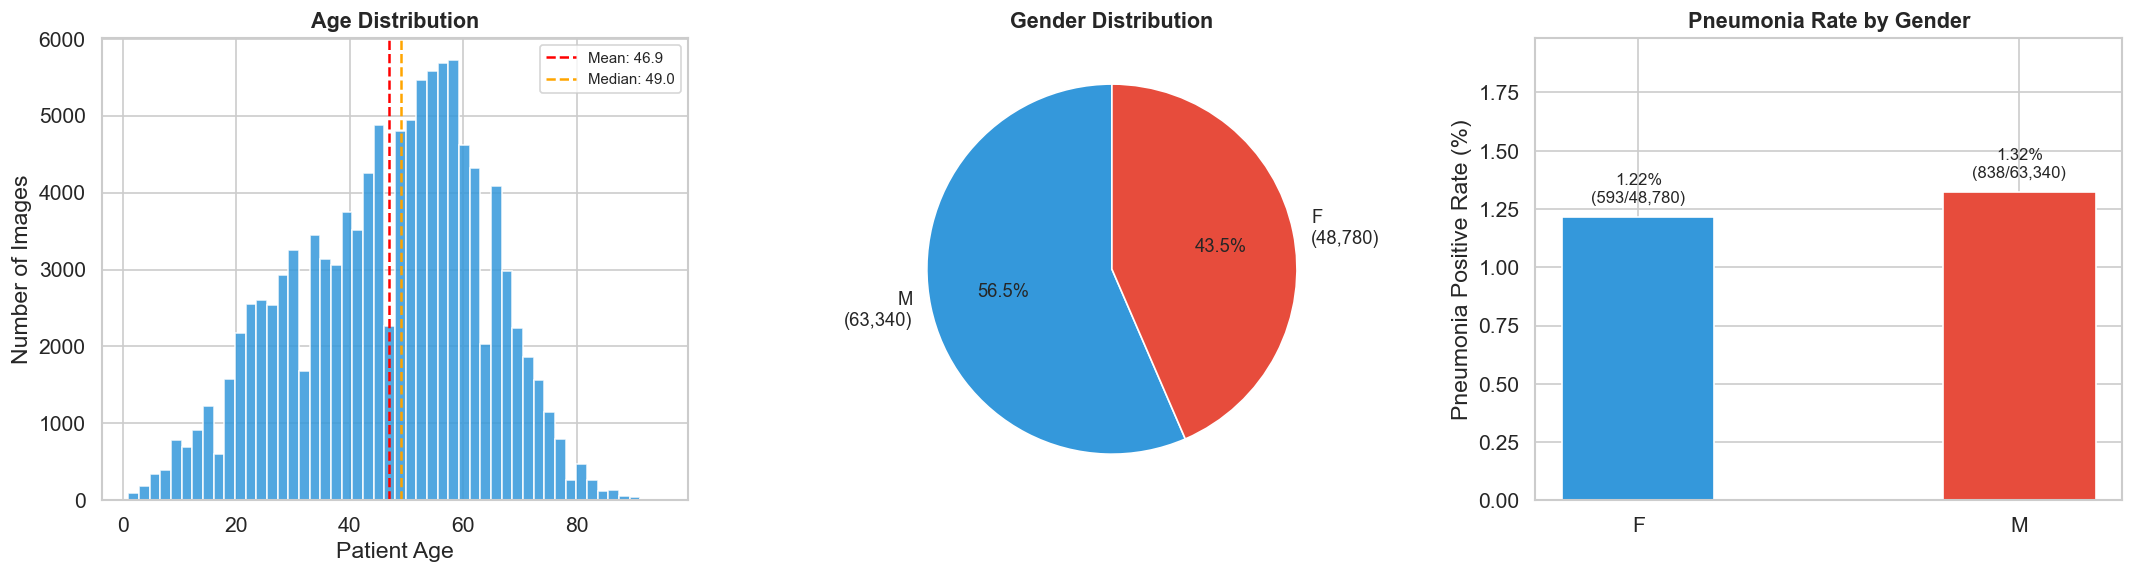

[SAVED] outputs/eda/demographics.png

Age statistics (valid ages 0-120):
count    112104.000000
mean         46.872574
std          16.598152
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max          95.000000

Gender distribution:
patient_gender
M    63340
F    48780

Pneumonia rate by gender:
                Positive  Total      Rate  Rate_pct
patient_gender                                     
F                    593  48780  0.012157  1.215662
M                    838  63340  0.013230  1.323019


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5a: Age distribution
ax = axes[0]
# Filter out unrealistic ages
valid_ages = df_all['patient_age'][(df_all['patient_age'] >= 0) & (df_all['patient_age'] <= 120)]
ax.hist(valid_ages, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(valid_ages.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {valid_ages.mean():.1f}')
ax.axvline(valid_ages.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {valid_ages.median():.1f}')
ax.set_xlabel('Patient Age')
ax.set_ylabel('Number of Images')
ax.set_title('Age Distribution', fontsize=13)
ax.legend(fontsize=9)

# 5b: Gender distribution
ax = axes[1]
gender_counts = df_all['patient_gender'].value_counts()
colors_gen = ['#3498db', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    gender_counts.values, 
    labels=[f'{g}\n({c:,})' for g, c in zip(gender_counts.index, gender_counts.values)],
    colors=colors_gen, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 11}
)
ax.set_title('Gender Distribution', fontsize=13)

# 5c: Pneumonia rate by gender
ax = axes[2]
gender_pneumonia = df_all.groupby('patient_gender')['target_pneumonia'].agg(['sum', 'count', 'mean'])
gender_pneumonia.columns = ['Positive', 'Total', 'Rate']
gender_pneumonia['Rate_pct'] = gender_pneumonia['Rate'] * 100

bars = ax.bar(gender_pneumonia.index, gender_pneumonia['Rate_pct'],
              color=['#3498db', '#e74c3c'], edgecolor='white', width=0.4)
ax.set_ylabel('Pneumonia Positive Rate (%)')
ax.set_title('Pneumonia Rate by Gender', fontsize=13)

for bar, (idx, row) in zip(bars, gender_pneumonia.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["Rate_pct"]:.2f}%\n({int(row["Positive"]):,}/{int(row["Total"]):,})',
            ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, gender_pneumonia['Rate_pct'].max() * 1.5)

plt.tight_layout()
fig.savefig(EDA_OUTPUT / 'demographics.png')
plt.show()
print('[SAVED] outputs/eda/demographics.png')

# Print summary
print('\nAge statistics (valid ages 0-120):')
print(valid_ages.describe().to_string())
print('\nGender distribution:')
print(gender_counts.to_string())
print('\nPneumonia rate by gender:')
print(gender_pneumonia.to_string())

**Observation:** The dataset contains a roughly balanced gender split (approximately 56% male, 44% female). The age distribution peaks in the 40--60 range.  
Pneumonia rates may differ slightly by gender, but the overall pattern of severe class imbalance holds for both groups.

---
## 6 — View Position Analysis

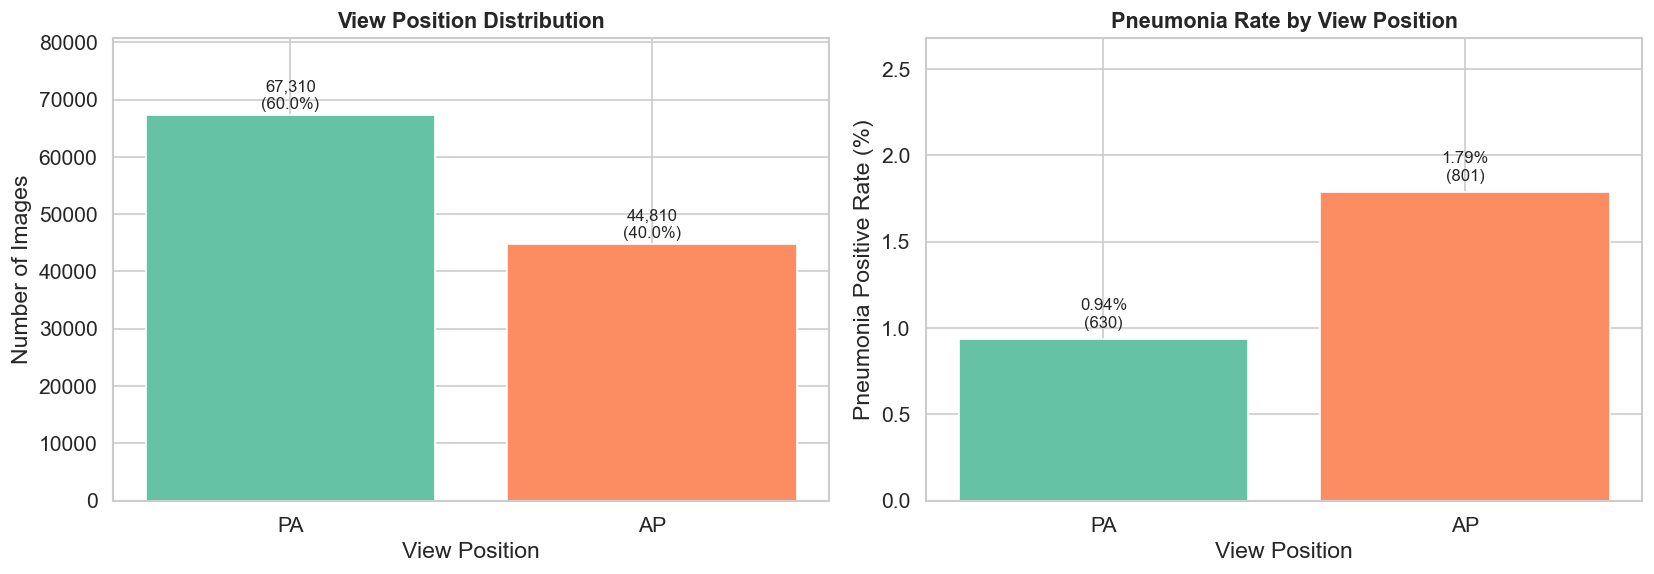

[SAVED] outputs/eda/view_position.png

View position counts:
view_position
PA    67310
AP    44810

Pneumonia rate by view position:
               Positive  Total      Rate  Rate_pct
view_position                                     
PA                  630  67310  0.009360  0.935968
AP                  801  44810  0.017875  1.787547


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6a: View position distribution
ax = axes[0]
vp_counts = df_all['view_position'].value_counts()
vp_colors = sns.color_palette('Set2', n_colors=len(vp_counts))
bars = ax.bar(vp_counts.index, vp_counts.values, color=vp_colors, edgecolor='white')
ax.set_xlabel('View Position')
ax.set_ylabel('Number of Images')
ax.set_title('View Position Distribution', fontsize=13)
for bar, count in zip(bars, vp_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}\n({count/len(df_all)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, vp_counts.max() * 1.2)

# 6b: Pneumonia rate by view position
ax = axes[1]
vp_pneumonia = df_all.groupby('view_position')['target_pneumonia'].agg(['sum', 'count', 'mean'])
vp_pneumonia.columns = ['Positive', 'Total', 'Rate']
vp_pneumonia['Rate_pct'] = vp_pneumonia['Rate'] * 100
vp_pneumonia = vp_pneumonia.sort_values('Total', ascending=False)

bars = ax.bar(vp_pneumonia.index, vp_pneumonia['Rate_pct'],
              color=vp_colors[:len(vp_pneumonia)], edgecolor='white')
ax.set_xlabel('View Position')
ax.set_ylabel('Pneumonia Positive Rate (%)')
ax.set_title('Pneumonia Rate by View Position', fontsize=13)

for bar, (idx, row) in zip(bars, vp_pneumonia.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["Rate_pct"]:.2f}%\n({int(row["Positive"]):,})',
            ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, vp_pneumonia['Rate_pct'].max() * 1.5)

plt.tight_layout()
fig.savefig(EDA_OUTPUT / 'view_position.png')
plt.show()
print('[SAVED] outputs/eda/view_position.png')

# Print summary
print('\nView position counts:')
print(vp_counts.to_string())
print('\nPneumonia rate by view position:')
print(vp_pneumonia.to_string())

**Observation:** The vast majority of images are PA (posteroanterior) views. AP (anteroposterior) views are less common.  
Pneumonia rates may differ between view positions, which is clinically expected since PA views are typically obtained for stable outpatients while AP views are more common in ICU/bedside settings.

---
## 7 — Sample Image Visualization

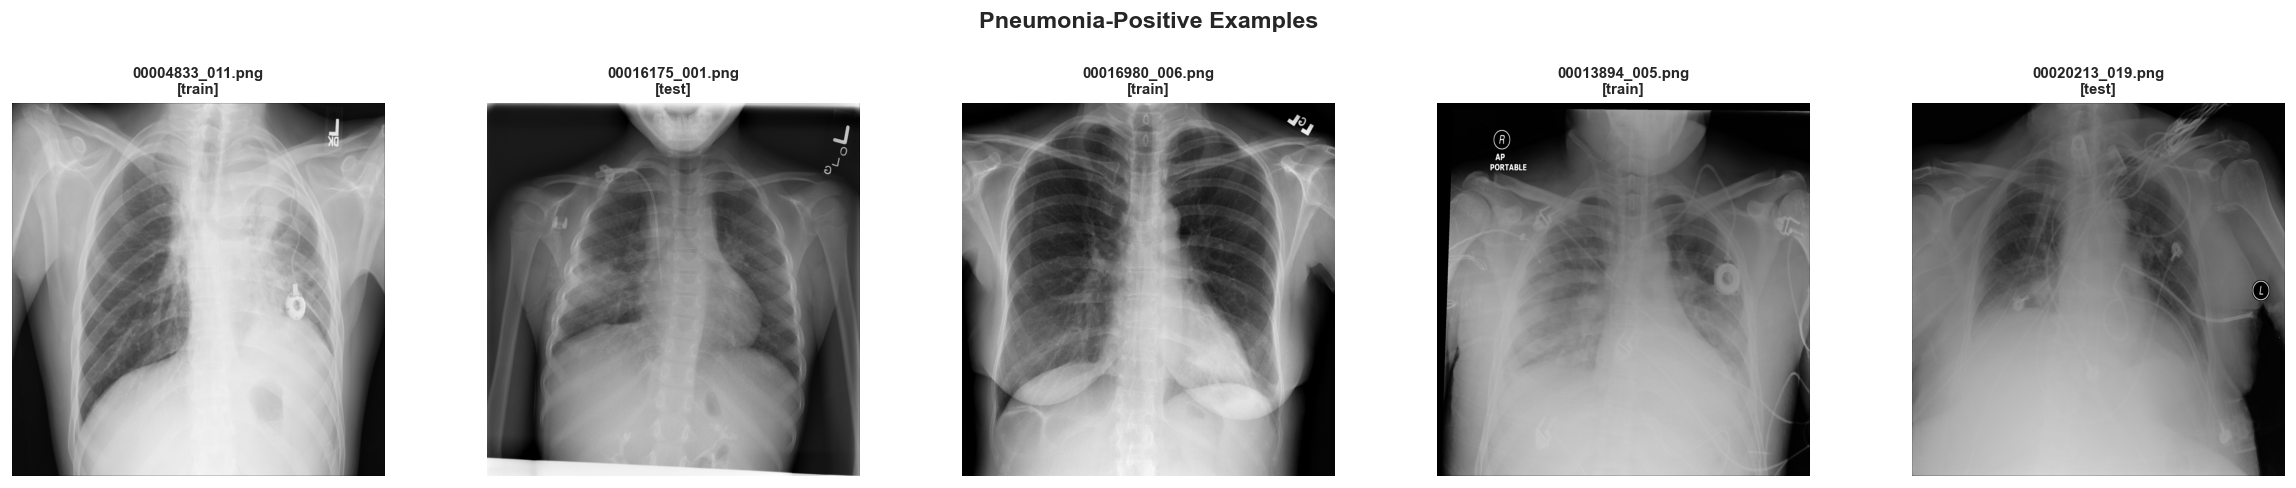

[SAVED] outputs/eda/sample_pneumonia_positive.png


In [11]:
def show_sample_images(df_split, label, n_samples=4, title_prefix=''):
    """Display a row of sample chest X-ray images."""
    samples = df_split.sample(n=min(n_samples, len(df_split)), random_state=42)
    
    fig, axes = plt.subplots(1, n_samples, figsize=(4*n_samples, 4))
    if n_samples == 1:
        axes = [axes]
    
    for ax, (_, row) in zip(axes, samples.iterrows()):
        try:
            img = Image.open(row['image_path'])
            ax.imshow(img, cmap='gray')
            split_label = row.get('split_source', 'unknown')
            ax.set_title(f"{row['image_name']}\n[{split_label}]", fontsize=9)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error loading\n{row["image_name"]}',
                    transform=ax.transAxes, ha='center', va='center')
        ax.axis('off')
    
    fig.suptitle(f'{title_prefix}{label}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

# Pneumonia-positive samples
pos_all = df_all[df_all['target_pneumonia'] == 1]
fig_pos = show_sample_images(pos_all, 'Pneumonia-Positive Examples', n_samples=5)
fig_pos.savefig(EDA_OUTPUT / 'sample_pneumonia_positive.png', bbox_inches='tight')
plt.show()
print('[SAVED] outputs/eda/sample_pneumonia_positive.png')

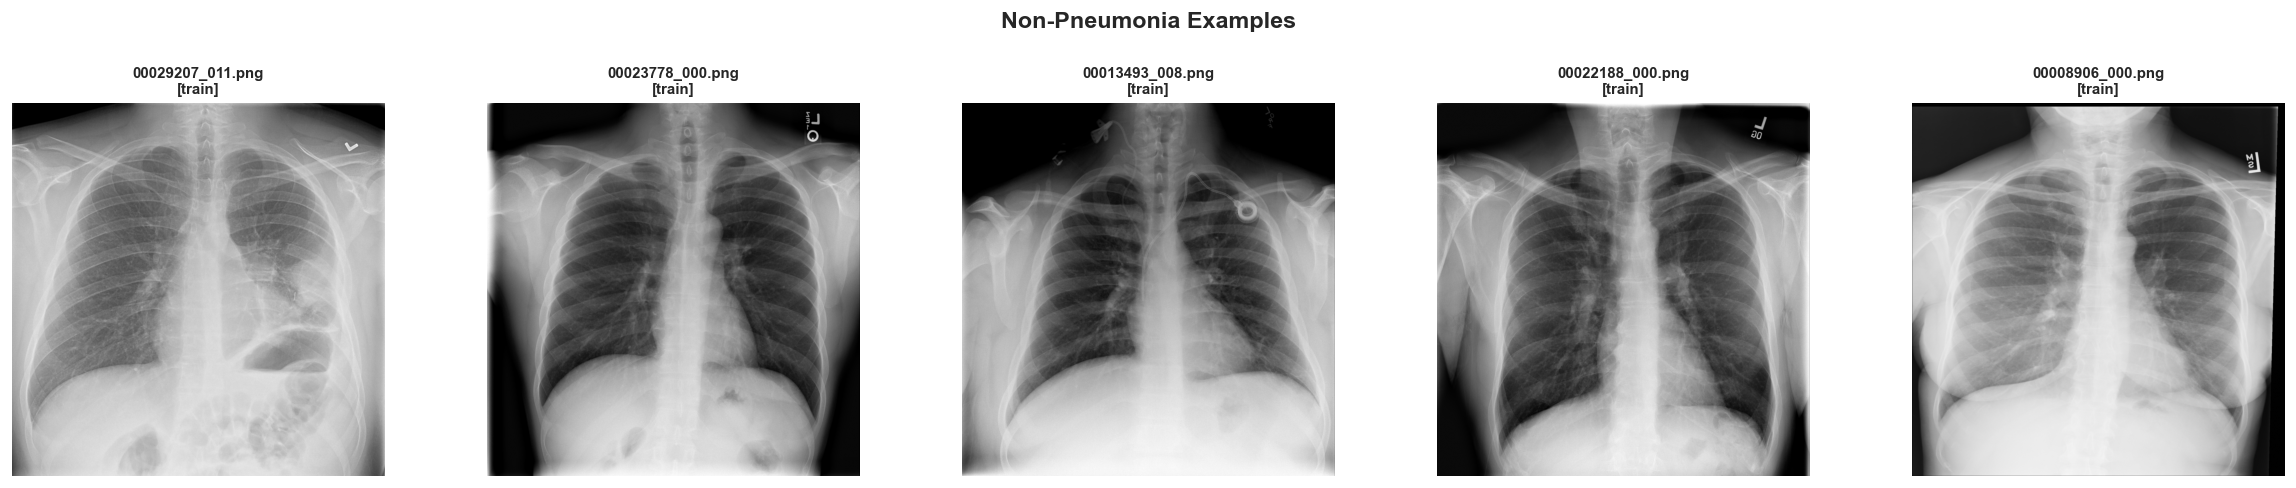

[SAVED] outputs/eda/sample_non_pneumonia.png


In [12]:
# Non-pneumonia samples
neg_all = df_all[df_all['target_pneumonia'] == 0]
fig_neg = show_sample_images(neg_all, 'Non-Pneumonia Examples', n_samples=5)
fig_neg.savefig(EDA_OUTPUT / 'sample_non_pneumonia.png', bbox_inches='tight')
plt.show()
print('[SAVED] outputs/eda/sample_non_pneumonia.png')

**Observation:** Chest X-ray images are grayscale PNG files at 1024x1024 resolution. Pneumonia is often characterized by opacification (white regions) in the lung fields, but subtle cases can be difficult to distinguish visually. Non-pneumonia images include healthy lungs and other pathologies.

---
## 8 — Image Property Checks

In [13]:
# Sample a few images to check properties
sample_for_check = df_all.sample(n=20, random_state=42)

img_properties = []
for _, row in sample_for_check.iterrows():
    try:
        img = Image.open(row['image_path'])
        img_properties.append({
            'image_name': row['image_name'],
            'width': img.size[0],
            'height': img.size[1],
            'mode': img.mode,
            'format': img.format,
        })
    except Exception as e:
        img_properties.append({
            'image_name': row['image_name'],
            'width': None, 'height': None, 'mode': 'ERROR', 'format': str(e)
        })

df_props = pd.DataFrame(img_properties)
print('Image Property Summary (from 20 sampled images):')
print(f"  Unique dimensions : {df_props[['width', 'height']].drop_duplicates().values.tolist()}")
print(f"  Color modes       : {df_props['mode'].unique().tolist()}")
print(f"  File formats      : {df_props['format'].unique().tolist()}")
print(f"  Any errors        : {(df_props['mode'] == 'ERROR').sum()}")

print('\nDetailed sample:')
print(df_props.to_string(index=False))

Image Property Summary (from 20 sampled images):
  Unique dimensions : [[1024, 1024]]
  Color modes       : ['L']
  File formats      : ['PNG']
  Any errors        : 0

Detailed sample:
      image_name  width  height mode format
00004893_012.png   1024    1024    L    PNG
00017421_001.png   1024    1024    L    PNG
00021272_000.png   1024    1024    L    PNG
00008301_000.png   1024    1024    L    PNG
00015845_008.png   1024    1024    L    PNG
00003191_000.png   1024    1024    L    PNG
00004913_000.png   1024    1024    L    PNG
00030079_036.png   1024    1024    L    PNG
00006317_000.png   1024    1024    L    PNG
00012257_001.png   1024    1024    L    PNG
00030159_005.png   1024    1024    L    PNG
00006668_000.png   1024    1024    L    PNG
00021854_000.png   1024    1024    L    PNG
00018187_067.png   1024    1024    L    PNG
00017098_004.png   1024    1024    L    PNG
00029174_000.png   1024    1024    L    PNG
00009609_005.png   1024    1024    L    PNG
00013249_018.png   102

In [14]:
# Check metadata-reported dimensions from original Data_Entry CSV
if 'OriginalImage[Width' in df_meta.columns and 'Height]' in df_meta.columns:
    print('Original image dimensions from metadata:')
    print(f"  Width  range: {df_meta['OriginalImage[Width'].min()} - {df_meta['OriginalImage[Width'].max()}")
    print(f"  Height range: {df_meta['Height]'].min()} - {df_meta['Height]'].max()}")
    
    # Most common dimensions
    dims = df_meta[['OriginalImage[Width', 'Height]']].value_counts().head(5)
    print(f'\nTop 5 original image dimensions (before any resizing):')
    for (w, h), count in dims.items():
        print(f'  {w} x {h} : {count:,} images ({count/len(df_meta)*100:.1f}%)')

print('\n--- Image Property Summary ---')
print('- All images are grayscale PNG files')
print('- Current on-disk resolution: 1024 x 1024 (after NIH preprocessing)')
print('- Original resolutions varied (metadata shows original dimensions)')
print('- All 112,120 image paths were resolved successfully during preprocessing')

Original image dimensions from metadata:
  Width  range: 1143 - 3827
  Height range: 966 - 4715

Top 5 original image dimensions (before any resizing):
  2500 x 2048 : 37,153 images (33.1%)
  2992 x 2991 : 21,961 images (19.6%)
  3056 x 2544 : 15,340 images (13.7%)
  2048 x 2500 : 8,683 images (7.7%)
  2021 x 2021 : 4,411 images (3.9%)

--- Image Property Summary ---
- All images are grayscale PNG files
- Current on-disk resolution: 1024 x 1024 (after NIH preprocessing)
- Original resolutions varied (metadata shows original dimensions)
- All 112,120 image paths were resolved successfully during preprocessing


**Observation:** All images are stored as grayscale (mode `L`) PNG files at 1024x1024 resolution. The original images had varying dimensions before NIH standardization. All 112,120 image paths were successfully resolved during preprocessing.

---
## 9 — Key EDA Findings

### Summary of Major Findings

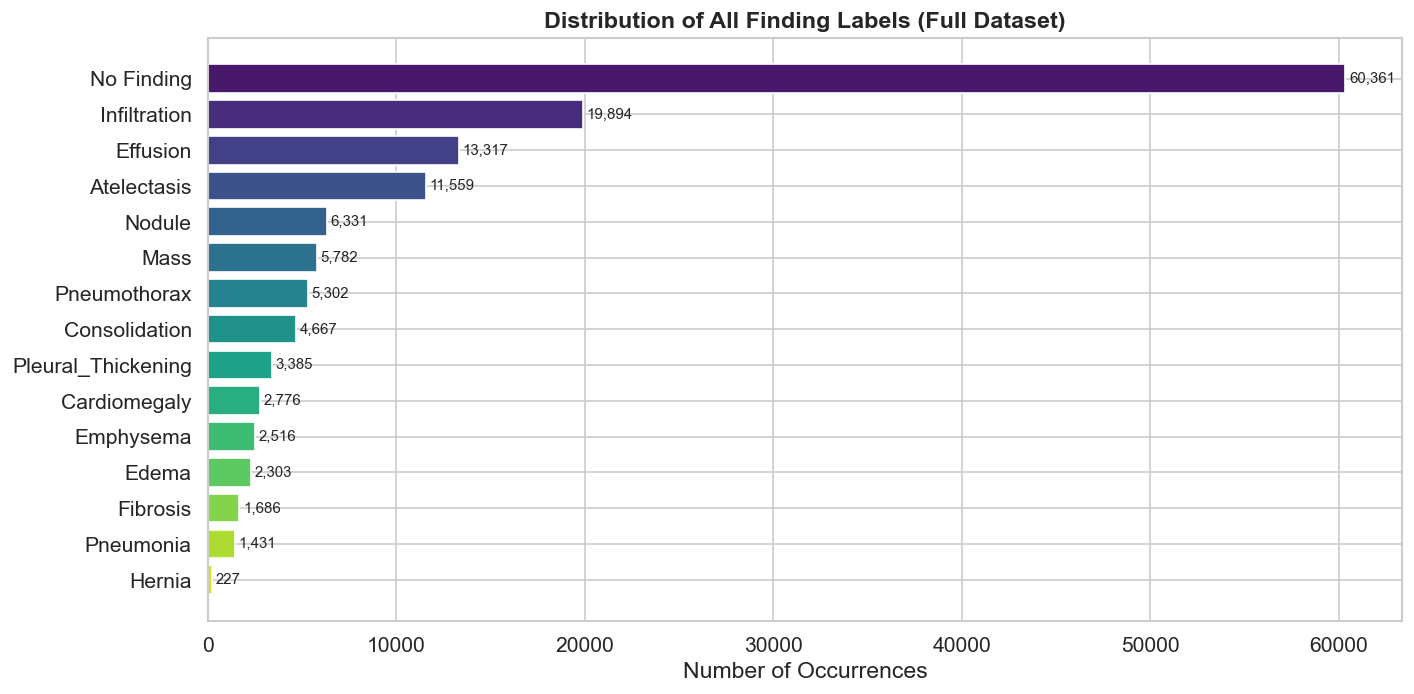

[SAVED] outputs/eda/finding_labels_distribution.png

Total unique label combinations: 836

Label frequency:
  No Finding                :  60,361  (53.84%)
  Infiltration              :  19,894  (17.74%)
  Effusion                  :  13,317  (11.88%)
  Atelectasis               :  11,559  (10.31%)
  Nodule                    :   6,331  ( 5.65%)
  Mass                      :   5,782  ( 5.16%)
  Pneumothorax              :   5,302  ( 4.73%)
  Consolidation             :   4,667  ( 4.16%)
  Pleural_Thickening        :   3,385  ( 3.02%)
  Cardiomegaly              :   2,776  ( 2.48%)
  Emphysema                 :   2,516  ( 2.24%)
  Edema                     :   2,303  ( 2.05%)
  Fibrosis                  :   1,686  ( 1.50%)
  Pneumonia                 :   1,431  ( 1.28%) <-- TARGET
  Hernia                    :     227  ( 0.20%)


In [15]:
# Multi-label distribution in the full dataset
all_labels = df_all['finding_labels'].str.split('|').explode()
label_counts = all_labels.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = sns.color_palette('viridis', n_colors=len(label_counts))
bars = ax.barh(label_counts.index[::-1], label_counts.values[::-1],
               color=colors_bar[::-1], edgecolor='white')
ax.set_xlabel('Number of Occurrences')
ax.set_title('Distribution of All Finding Labels (Full Dataset)', fontsize=14)

for bar, count in zip(bars, label_counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
fig.savefig(EDA_OUTPUT / 'finding_labels_distribution.png')
plt.show()
print('[SAVED] outputs/eda/finding_labels_distribution.png')

print(f'\nTotal unique label combinations: {df_all["finding_labels"].nunique()}')
print(f'\nLabel frequency:')
for label, count in label_counts.items():
    pct = count / len(df_all) * 100
    marker = ' <-- TARGET' if label == 'Pneumonia' else ''
    print(f'  {label:25s} : {count:>7,}  ({pct:5.2f}%){marker}')

> **Note on "No Finding":** The label `No Finding` indicates that *none of the 14 pathology classes* were detected by the NLP labeling pipeline. 
It does **not** mean the image is clinically "normal" — a patient may still have conditions outside the 14 target categories 
(e.g., rib fractures, foreign bodies, or surgical changes). 
Therefore, `No Finding` should be interpreted as "no *labeled* pathology," not as a confirmed healthy baseline.

In [16]:
# Final EDA summary — printable for Phase 2 report
print('=' * 70)
print('EDA SUMMARY — TEAM 505 PHASE 2')
print('=' * 70)
print()
print('Dataset: NIH ChestX-ray14')
print(f'Total images: {len(df_all):,} | Total patients: {df_all["patient_id"].nunique():,}')
print(f'Task: Binary pneumonia classification')
print(f'Pneumonia positive rate: {df_all["target_pneumonia"].mean()*100:.2f}%')
print()
print('SPLITS:')
print(f'  Train      : {len(df_train):>7,} images, {df_train["patient_id"].nunique():>6,} patients, '
      f'{df_train["target_pneumonia"].sum():>4} pos ({df_train["target_pneumonia"].mean()*100:.2f}%)')
print(f'  Validation : {len(df_val):>7,} images, {df_val["patient_id"].nunique():>6,} patients, '
      f'{df_val["target_pneumonia"].sum():>4} pos ({df_val["target_pneumonia"].mean()*100:.2f}%)')
print(f'  Test (NIH) : {len(df_test):>7,} images, {df_test["patient_id"].nunique():>6,} patients, '
      f'{df_test["target_pneumonia"].sum():>4} pos ({df_test["target_pneumonia"].mean()*100:.2f}%)')
print(f'  Train_dev  : {len(df_train_dev):>7,} images, {df_train_dev["patient_id"].nunique():>6,} patients, '
      f'{df_train_dev["target_pneumonia"].sum():>4} pos ({df_train_dev["target_pneumonia"].mean()*100:.2f}%)')
print()
print('KEY FINDINGS:')
print('  1. SEVERE CLASS IMBALANCE: Only 1.28% of images are pneumonia-positive.')
print('     Weighted loss or oversampling will be essential during training.')
print('  2. OFFICIAL NIH TEST SPLIT PRESERVED: 25,596 test images from 2,797 patients.')
print('     This ensures comparability with published benchmarks.')
print('  3. PATIENT-WISE SPLITTING: Zero patient overlap between train/val/test.')
print('     This prevents data leakage from follow-up studies.')
print('  4. TRAIN_DEV SUBSET: 8,085 images enriched with all pneumonia patients.')
print('     Positive rate ~9.2% enables faster dev cycles.')
print('  5. MULTI-LABEL CONTEXT: Images may contain multiple pathologies.')
print('     Pneumonia often co-occurs with infiltration and effusion.')
print('  6. VIEW POSITION: Predominantly PA views; AP views may have different')
print('     pneumonia prevalence (ICU patients).')
print('  7. DEMOGRAPHICS: Roughly balanced gender split; age peaks in 40-60 range.')
print('  8. IMAGE FORMAT: All 1024x1024 grayscale PNGs; all paths resolved.')
print()
print('=' * 70)

EDA SUMMARY — TEAM 505 PHASE 2

Dataset: NIH ChestX-ray14
Total images: 112,120 | Total patients: 30,805
Task: Binary pneumonia classification
Pneumonia positive rate: 1.28%

SPLITS:
  Train      :  73,916 images, 23,806 patients,  742 pos (1.00%)
  Validation :  12,608 images,  4,202 patients,  134 pos (1.06%)
  Test (NIH) :  25,596 images,  2,797 patients,  555 pos (2.17%)
  Train_dev  :   8,085 images,    587 patients,  742 pos (9.18%)

KEY FINDINGS:
  1. SEVERE CLASS IMBALANCE: Only 1.28% of images are pneumonia-positive.
     Weighted loss or oversampling will be essential during training.
  2. OFFICIAL NIH TEST SPLIT PRESERVED: 25,596 test images from 2,797 patients.
     This ensures comparability with published benchmarks.
  3. PATIENT-WISE SPLITTING: Zero patient overlap between train/val/test.
     This prevents data leakage from follow-up studies.
  4. TRAIN_DEV SUBSET: 8,085 images enriched with all pneumonia patients.
     Positive rate ~9.2% enables faster dev cycles.
  5

---
## 10 — Figure Export Summary

In [17]:
# List all saved figures
print('Saved figures in outputs/eda/:')
print('-' * 50)
saved_files = sorted(EDA_OUTPUT.glob('*.png'))
for f in saved_files:
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:45s} ({size_kb:.1f} KB)')
print(f'\nTotal figures saved: {len(saved_files)}')
print(f'Output directory: {EDA_OUTPUT}')

Saved figures in outputs/eda/:
--------------------------------------------------
  class_distribution.png                        (81.5 KB)
  demographics.png                              (111.9 KB)
  finding_labels_distribution.png               (82.9 KB)
  patient_analysis.png                          (85.1 KB)
  pos_rate_by_split.png                         (41.8 KB)
  sample_non_pneumonia.png                      (699.6 KB)
  sample_pneumonia_positive.png                 (650.6 KB)
  view_position.png                             (75.7 KB)

Total figures saved: 8
Output directory: C:\Users\s-amm\Downloads\ChestX-ray14\Team505_phase2\outputs\eda


---

**End of EDA Notebook**  
Ready for model training (Phase 2).

---